# Two steps Neural Networks

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os
from itertools import product

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Data preparation

In [2]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations.txt")
file_path_diff = os.path.join("..", "..", "Diffusion\DATA", "diffusion.txt")



Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)

diffusion= np.loadtxt(
    file_path_diff
).astype(
    int
)

In [3]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)

In [4]:
########################     NORMALIZATION  #########################
# Input

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [5]:
#########################     TRAIN SET      ##########################
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoHF = 3000  # number of epochs for second NN: NN_HF

Nlf = 30


In [6]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation1][0:n_HF]
x_HF = x_HF_test[permutation2][0:n_HF]
reaction_HF = np.column_stack((reaction_HF, x_HF))
U_HF_test = U_HF_test[:, -1, :,44]

reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), x_HF_test.flatten())))

# TRANSFORMATION
U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

##
U_HF = U_HF_test[permutation1[0:n_HF],permutation2[0:n_HF]]
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##

In [7]:
U_LF_list = []
U_HF_list = []

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
16/16 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.26559997305513094
R^2: -1.1273343105231186
157/157 [==============================] - 0s 2ms/step
Elapsed time:  86.40724239998963

HF Model:
Test MSE: 0.7252546660324634
R^2: -5.494849478709535
157/157 [==============================] - 0s 2ms/step


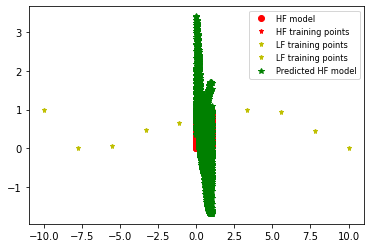

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
16/16 [==============================] - 0s 1ms/step

LF Model:
Test MSE: 0.2560905900465506
R^2: -1.0699822798166725
157/157 [==============================] - 0s 2ms/step
Elapsed time:  85.23189009999624

HF Model:
Test MSE: 0.48277340365355215
R^2: -3.3233649308417554
157/157 [==============================] - 0s 2ms/step


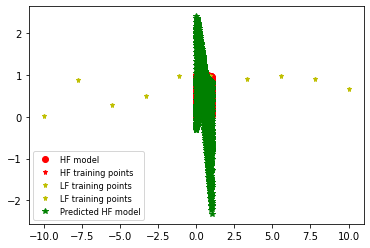

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
16/16 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.2354503485708208
R^2: -0.9166819654256022
157/157 [==============================] - 1s 3ms/step
Elapsed time:  124.02482689998578

HF Model:
Test MSE: 1.4497615560333652
R^2: -11.983002423089486
157/157 [==============================] - 0s 3ms/step


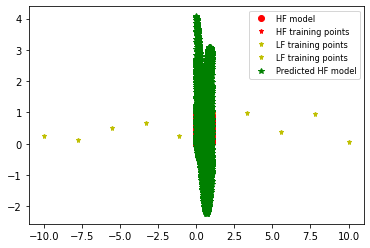

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
16/16 [==============================] - 0s 749us/step

LF Model:
Test MSE: 0.22071965256325046
R^2: -0.8507063891788755
157/157 [==============================] - 0s 2ms/step
Elapsed time:  143.72740319999866

HF Model:
Test MSE: 0.4203093257219154
R^2: -2.7639824090970375
157/157 [==============================] - 0s 2ms/step


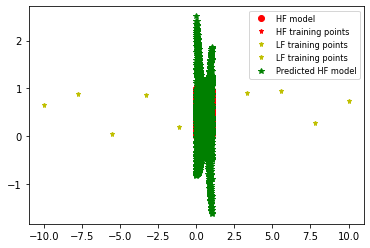

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
44/44 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.2612080355595976
R^2: -1.0943626349104583
157/157 [==============================] - 1s 3ms/step
Elapsed time:  88.95084250002401

HF Model:
Test MSE: 0.6316953831469923
R^2: -4.6570010812613205
157/157 [==============================] - 1s 3ms/step


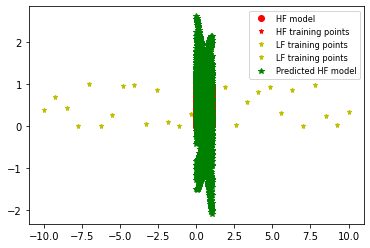

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
44/44 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.14284897631973642
R^2: -0.27581206843341266
157/157 [==============================] - 1s 3ms/step
Elapsed time:  143.8091560000321

HF Model:
Test MSE: 1.4374296713736014
R^2: -11.872567098223355
157/157 [==============================] - 0s 2ms/step


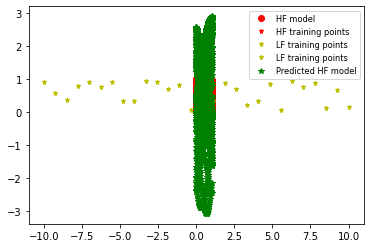

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
44/44 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.24151657082777656
R^2: -1.2228381108387474
157/157 [==============================] - 0s 2ms/step
Elapsed time:  86.56895489996532

HF Model:
Test MSE: 0.722486838501819
R^2: -5.470062843012443
157/157 [==============================] - 0s 2ms/step


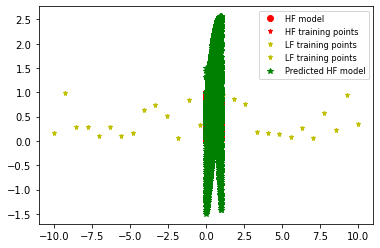

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
44/44 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.19798905178641218
R^2: -0.840719901660973
157/157 [==============================] - 0s 2ms/step
Elapsed time:  100.6633038999862

HF Model:
Test MSE: 0.7476956429626436
R^2: -5.695814428185904
157/157 [==============================] - 0s 2ms/step


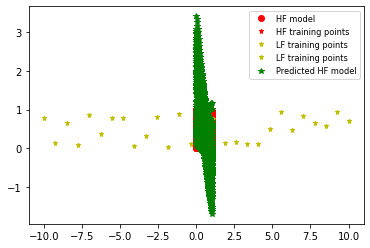

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.2768726336491906
R^2: -1.2199818498418957
157/157 [==============================] - 0s 2ms/step
Elapsed time:  90.05414360004943

HF Model:
Test MSE: 0.5601820277119977
R^2: -4.016579859556345
157/157 [==============================] - 0s 2ms/step


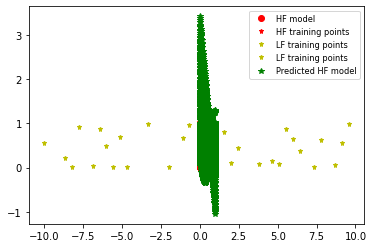

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.18766157745516102
R^2: -0.6981870631859097
157/157 [==============================] - 0s 2ms/step
Elapsed time:  86.74083239998436

HF Model:
Test MSE: 3.4502562530955125
R^2: -29.897967398707717
157/157 [==============================] - 0s 3ms/step


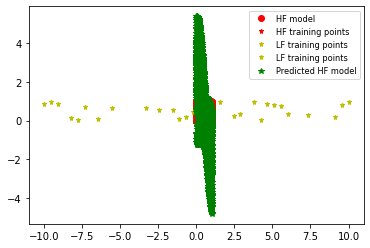

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.16702446828517464
R^2: -0.5179284001981204
157/157 [==============================] - 0s 2ms/step
Elapsed time:  85.5571780000464

HF Model:
Test MSE: 0.6415347723993245
R^2: -4.745115443221827
157/157 [==============================] - 0s 2ms/step


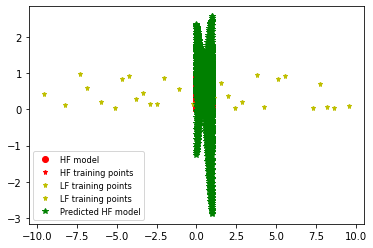

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.16521241442008258
R^2: -0.5113971842754859
157/157 [==============================] - 0s 2ms/step
Elapsed time:  93.38627070002258

HF Model:
Test MSE: 0.31997669628290515
R^2: -1.8654768819635597
157/157 [==============================] - 0s 2ms/step


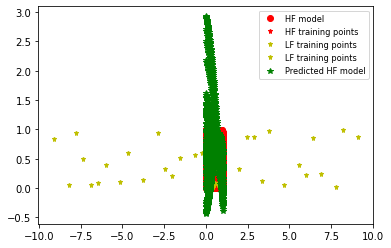

    Discretization  diffusion        R2
0             10.0        0.0  -5.49485
1             10.0        5.0  -3.32336
2             10.0       75.0 -11.98300
3             10.0        1.0  -2.76398
4             28.0        0.0  -4.65700
5             28.0        5.0 -11.87257
6             28.0       75.0  -5.47006
7             28.0        1.0  -5.69581
8             46.0        0.0  -4.01658
9             46.0        5.0 -29.89797
10            46.0       75.0  -4.74512
11            46.0        1.0  -1.86548
    Discretization  diffusion      MSE
0             10.0        0.0  0.72525
1             10.0        5.0  0.48277
2             10.0       75.0  1.44976
3             10.0        1.0  0.42031
4             28.0        0.0  0.63170
5             28.0        5.0  1.43743
6             28.0       75.0  0.72249
7             28.0        1.0  0.74770
8             46.0        0.0  0.56018
9             46.0        5.0  3.45026
10            46.0       75.0  0.64153
11          

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:177: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_7312\1558210663.py:179: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

In [27]:

test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat")
        #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, x_LF_test) = import_data(file_name)
#file_path_LF = "..\..\Diffusion\DATA\reaction_diffusion_LF_46_d75.mat"
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        L=np.minimum(Nlf,x_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(x_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:L]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        x_LF = x_LF_test[permutation2][0:L]
        reaction_LF = np.column_stack((reaction_LF, x_LF))
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), x_LF_test.flatten())))
        U_LF_test = U_LF_test[
        :,
        - 1,
        :,
        int(4*(Discretizations[m]-1)/9)
        ]
        # TRANSFORMATION
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)

        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
        #U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
        U_train_LF = U_LF_test[permutation1[0:L],permutation2[0:L]]
        ##
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]
        ##      


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 

        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        #        histLF = modelLF.fit(Young_LF_norm[:,0], U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )

        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_in),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()

        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [28]:
os.makedirs("MF_LF_30_5000_HF_15_3000_2NN_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_30_5000_HF_15_3000_2NN_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_30_5000_HF_15_3000_2NN_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)